# Tesla Reviews Sentiment — бинарная классификация / binary classification

**RU.** Учебный проект по распознаванию позитивных и негативных отзывов владельцев автомобилей Tesla. База — два текстовых файла (положительные и отрицательные отзывы). Ноутбук демонстрирует полный цикл NLP-классификации: чтение и чистка текста (включая эмодзи), балансировка классов, токенизация, нарезка скользящим окном, обучение сети `Embedding → GlobalAveragePooling1D → Dense`. Целевой уровень точности 85–90 % на валидации.

**EN.** A study project on positive vs. negative sentiment classification of Tesla owner reviews. The dataset consists of two text files (positive and negative reviews). The notebook demonstrates a complete NLP-classification pipeline: text reading and cleaning (including emojis), class balancing, tokenisation, sliding-window slicing, and training an `Embedding → GlobalAveragePooling1D → Dense` network. The accuracy target is 85–90 % on the validation set.

**Dataset / датасет:** <https://storage.yandexcloud.net/aiueducation/Content/base/l7/tesla.zip>

## 1. Импорты / Imports

In [ ]:
import os
import re
from collections import Counter

import gdown
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

from tensorflow.keras import utils
from tensorflow.keras.layers import (
    BatchNormalization,
    Dense,
    Dropout,
    Embedding,
    GlobalAveragePooling1D,
    SpatialDropout1D,
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import Tokenizer

%matplotlib inline
plt.style.use("ggplot")

## 2. Загрузка и распаковка данных / Download and unzip

In [ ]:
DATA_URL = "https://storage.yandexcloud.net/aiueducation/Content/base/l7/tesla.zip"
DATA_DIR = "tesla"

gdown.download(DATA_URL, None, quiet=True)
!unzip -qo tesla.zip -d {DATA_DIR}/
!ls {DATA_DIR}

'Негативный отзыв.txt'	'Позитивный отзыв.txt'


## 3. Чтение файлов и предпросмотр / Read files and preview

**RU.** Явно указываем два файла — так порядок классов детерминирован и не зависит от `os.listdir`.

**EN.** We reference the two files by name so class ordering is deterministic and independent of `os.listdir`.

In [ ]:
CLASS_NAMES = ["Негативный отзыв", "Позитивный отзыв"]
CLASS_COUNT = len(CLASS_NAMES)


def read_text(file_path: str) -> str:
    """Прочитать файл и заменить переводы строк пробелами.

    Read a text file and replace newlines with spaces so the
    content is a single contiguous string of words.
    """
    with open(file_path, "r", encoding="utf-8") as f:
        return f.read().replace("\n", " ")


# Порядок текстов строго соответствует CLASS_NAMES.
# Order matches CLASS_NAMES exactly.
texts_list = [read_text(f"{DATA_DIR}/{name}.txt") for name in CLASS_NAMES]

for name, text in zip(CLASS_NAMES, texts_list):
    print(f"=== {name} ({len(text)} символов) ===")
    print(text[:400])
    print()

## 4. Статистика по символам / Per-character statistics

**RU.** Смотрим, какие специальные символы встречаются в текстах — помогает сформировать `filters` токенизатора и заметить неочевидные вещи вроде эмодзи.

**EN.** Inspect which special characters appear in the texts — this helps build the tokenizer's `filters` argument and notice non-obvious bits such as emojis.

In [ ]:
for name, text in zip(CLASS_NAMES, texts_list):
    counts = Counter(text)
    print(f"[{name}] топ-20 частых символов / top-20 chars: "
          f"{counts.most_common(20)}")

## 5. Разбиение 80 / 20 / Split 80 / 20

**RU.** Каждый текст делим 80 % на обучение, 20 % на валидацию.

**EN.** Each text is split 80 % for training and 20 % for validation.

In [ ]:
SPLIT_COEF = 0.8

train_text, test_text = [], []
for text in texts_list:
    split_at = int(len(text) * SPLIT_COEF)
    train_text.append(text[:split_at])
    test_text.append(text[split_at:])

for idx, name in enumerate(CLASS_NAMES):
    print(
        f"{name:<20} train={len(train_text[idx]):>8}  "
        f"test={len(test_text[idx]):>6}"
    )

## 6. Балансировка классов / Class balancing

**RU.** Позитивные отзывы заметно длиннее негативных — обрезаем длинный класс до размера короткого, чтобы модель увидела одинаковое количество сигнала на каждый класс.

**EN.** Positive reviews are noticeably longer than negative — we truncate the longer class down to the length of the shorter one so the model sees the same amount of signal per class.

In [ ]:
def balance_pair(texts: list[str]) -> list[str]:
    """Выровнять два текста по длине самого короткого.

    Truncate two-text list so both strings have the length of
    the shorter one. Returns a new list; originals are not
    modified.
    """
    assert len(texts) == 2, "Ожидается ровно два класса / exactly two classes expected"
    min_len = min(len(t) for t in texts)
    return [t[:min_len] for t in texts]


train_text = balance_pair(train_text)
test_text = balance_pair(test_text)

for idx, name in enumerate(CLASS_NAMES):
    print(
        f"{name:<20} train={len(train_text[idx]):>8}  "
        f"test={len(test_text[idx]):>6}"
    )

## 7. Удаление эмодзи / Emoji removal

**RU.** Эмодзи в отзывах попадают в словарь и засоряют `embedding` редкими, но шумными токенами — удаляем их регулярным выражением по unicode-диапазонам.

**EN.** Emojis end up in the vocabulary and pollute the embedding with rare, noisy tokens — strip them with a regex matching the unicode ranges.

In [ ]:
EMOJI_PATTERN = re.compile(
    "["
    "\U0001F600-\U0001F64F"   # smileys
    "\U0001F300-\U0001F5FF"   # symbols and pictographs
    "\U0001F680-\U0001F6FF"   # transport
    "\U0001F1E0-\U0001F1FF"   # flags
    "\U00002702-\U000027B0"   # dingbats
    "\U000024C2-\U0001F251"
    "]+",
    flags=re.UNICODE,
)


def strip_emojis(text: str) -> str:
    """Убрать эмодзи из строки / remove emojis from a string."""
    return EMOJI_PATTERN.sub("", text)


train_text = [strip_emojis(t) for t in train_text]
test_text = [strip_emojis(t) for t in test_text]

for idx, name in enumerate(CLASS_NAMES):
    print(
        f"{name:<20} train={len(train_text[idx]):>8}  "
        f"test={len(test_text[idx]):>6}"
    )

## 8. Токенизация / Tokenisation

In [ ]:
VOCAB_SIZE = 10_000
WIN_SIZE = 500     # length of a sliding text window in tokens
WIN_HOP = 50       # step between consecutive windows

TOK_FILTERS = '!"#$%&()*+,-–—./…:;<=>?@[\\]^_`{|}~«»\t\n\xa0\ufeff'

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    filters=TOK_FILTERS,
    lower=True,
    split=" ",
    oov_token="неизвестное_слово",
    char_level=False,
)
tokenizer.fit_on_texts(train_text)

seq_train = tokenizer.texts_to_sequences(train_text)
seq_test = tokenizer.texts_to_sequences(test_text)

print("Фрагмент токенизированного текста / tokenised fragment:")
print("  text:", train_text[1][:120])
print("  seq :", seq_train[1][:20])

In [ ]:
def print_text_stats(title: str, texts, sequences, class_labels=CLASS_NAMES) -> None:
    """Распечатать сводку по длинам текстов и их токенизированных версий.

    Print a per-class summary of character and token counts.
    """
    chars = words = 0
    print(f"Статистика по {title} текстам / {title} text stats:")
    for cls, name in enumerate(class_labels):
        print(f"  {name:<20} {len(texts[cls]):>9} символов   {len(sequences[cls]):>8} слов")
        chars += len(texts[cls])
        words += len(sequences[cls])
    print(f"  {'Сумма / total':<20} {chars:>9} символов   {words:>8} слов\n")


print_text_stats("обучающим / train", train_text, seq_train)
print_text_stats("тестовым / test", test_text, seq_test)

## 9. Нарезка скользящим окном / Sliding-window slicing

**RU.** Длинные последовательности индексов режутся на окна `500` слов с шагом `50` — это даёт достаточно обучающих примеров без потери контекста.

**EN.** Long index sequences are sliced into 500-word windows with a step of 50 — enough training samples without losing local context.

In [ ]:
def split_into_windows(sequence: list[int], win_size: int, hop: int) -> list[list[int]]:
    """Build sliding windows of length ``win_size`` with stride ``hop``."""
    return [
        sequence[i:i + win_size]
        for i in range(0, len(sequence) - win_size + 1, hop)
    ]


def vectorise_class_sequences(seq_list, win_size: int, hop: int):
    """Преобразовать список последовательностей в (X, y) с one-hot метками.

    Convert a per-class list of sequences into an ``(X, y)`` pair
    where every row of ``X`` is a window of ``win_size`` indices
    and ``y`` is the corresponding one-hot label.
    """
    n_classes = len(seq_list)
    x, y = [], []
    for cls in range(n_classes):
        windows = split_into_windows(seq_list[cls], win_size, hop)
        x.extend(windows)
        y.extend([utils.to_categorical(cls, n_classes)] * len(windows))
    return np.array(x), np.array(y)


x_train, y_train = vectorise_class_sequences(seq_train, WIN_SIZE, WIN_HOP)
x_test, y_test = vectorise_class_sequences(seq_test, WIN_SIZE, WIN_HOP)

print(f"x_train: {x_train.shape}  y_train: {y_train.shape}")
print(f"x_test : {x_test.shape}  y_test : {y_test.shape}")

## 10. Helpers: обучение + оценка / Training & evaluation helpers

In [ ]:
def plot_history(history, figsize=(20, 5)) -> None:
    """Кривые accuracy и loss для train / val."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle("Прогресс обучения / Training progress")

    ax1.plot(history.history["accuracy"], label="train")
    ax1.plot(history.history["val_accuracy"], label="val")
    ax1.set_title("Accuracy")
    ax1.set_xlabel("epoch")
    ax1.legend()

    ax2.plot(history.history["loss"], label="train")
    ax2.plot(history.history["val_loss"], label="val")
    ax2.set_title("Loss")
    ax2.set_xlabel("epoch")
    ax2.legend()
    plt.show()


def evaluate_classifier(model, x, y_true, class_labels: list[str],
                        title: str = "", figsize=(8, 8),
                        cm_round: int = 3) -> None:
    """Матрица ошибок и средняя точность / confusion matrix and mean accuracy.

    Evaluate a multi-class classifier on ``(x, y_true)`` using a
    normalised confusion matrix, print per-class results, and
    report the mean accuracy across the diagonal.
    """
    y_pred = model.predict(x)
    cm = confusion_matrix(
        np.argmax(y_true, axis=1),
        np.argmax(y_pred, axis=1),
        normalize="true",
    )
    cm = np.around(cm, cm_round)

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(f"{title}: confusion matrix (normalised)", fontsize=16)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=ax)
    plt.gca().images[-1].colorbar.remove()
    plt.xlabel("Predicted / предсказанные", fontsize=13)
    plt.ylabel("True / верные", fontsize=13)
    plt.show()

    print("-" * 80)
    for cls, name in enumerate(class_labels):
        pred_cls = int(np.argmax(cm[cls]))
        verdict = "ВЕРНО / OK" if pred_cls == cls else "НЕВЕРНО / wrong"
        print(
            f"{name:<20} → {class_labels[pred_cls]:<20}  "
            f"{100 * cm[cls, pred_cls]:6.1f}%   {verdict}"
        )
    print(f"\nСредняя точность / mean accuracy: {100 * cm.diagonal().mean():.1f}%")


def compile_train_evaluate(model, x_train, y_train, x_test, y_test,
                           class_labels=CLASS_NAMES,
                           title: str = "",
                           optimizer="adam",
                           loss: str = "binary_crossentropy",
                           epochs: int = 15,
                           batch_size: int = 16) -> None:
    """Скомпилировать, обучить и оценить модель в одном вызове.

    Compile, train, and evaluate the model in a single call.
    """
    model.compile(optimizer=optimizer, loss=loss, metrics=["accuracy"])
    model.summary()
    history = model.fit(
        x_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(x_test, y_test),
    )
    plot_history(history)
    evaluate_classifier(model, x_test, y_test, class_labels=class_labels, title=title)

## 11. Модель `Embedding → GlobalAveragePooling → Dense`

**RU.** Простая, но быстрая и точная архитектура для sentiment-задач: эмбеддинг превращает индексы в плотные вектора, `GlobalAveragePooling1D` усредняет их по окну, `BatchNormalization` + `Dense(relu)` + `Dropout` — регуляризованный классификатор поверх.

**EN.** A simple yet fast and accurate sentiment architecture: the embedding turns indices into dense vectors, `GlobalAveragePooling1D` averages them across the window, then `BatchNormalization` + `Dense(relu)` + `Dropout` form a regularised classifier on top.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9656 - loss: 0.4234 - val_accuracy: 0.9200 - val_loss: 0.6546
Epoch 2/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0301 - val_accuracy: 0.8533 - val_loss: 0.5940
Epoch 3/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0086 - val_accuracy: 0.9067 - val_loss: 0.5493
Epoch 4/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 0.0054 - val_accuracy: 0.9200 - val_loss: 0.5091
Epoch 5/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.9333 - val_loss: 0.4666
Epoch 6/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 0.9333 - val_loss: 0.4192
Epoch 7/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.9333 - val_loss: 0.3710
Epoch 8/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0030 - val_accuracy: 0.9200 - v

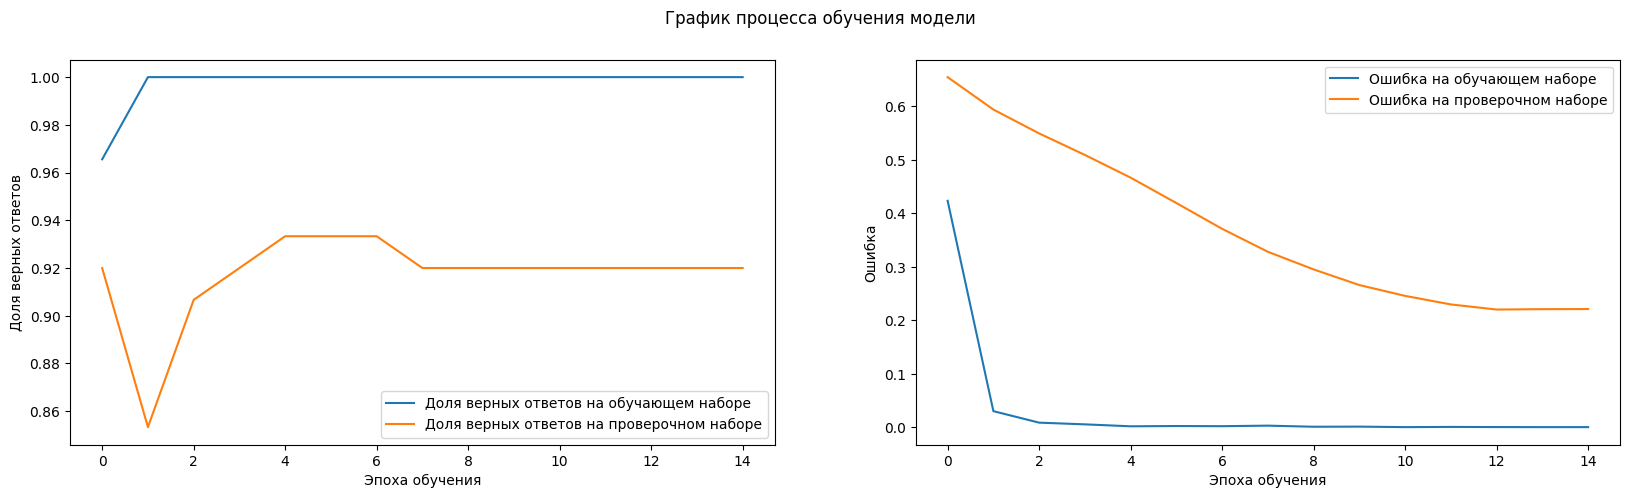

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


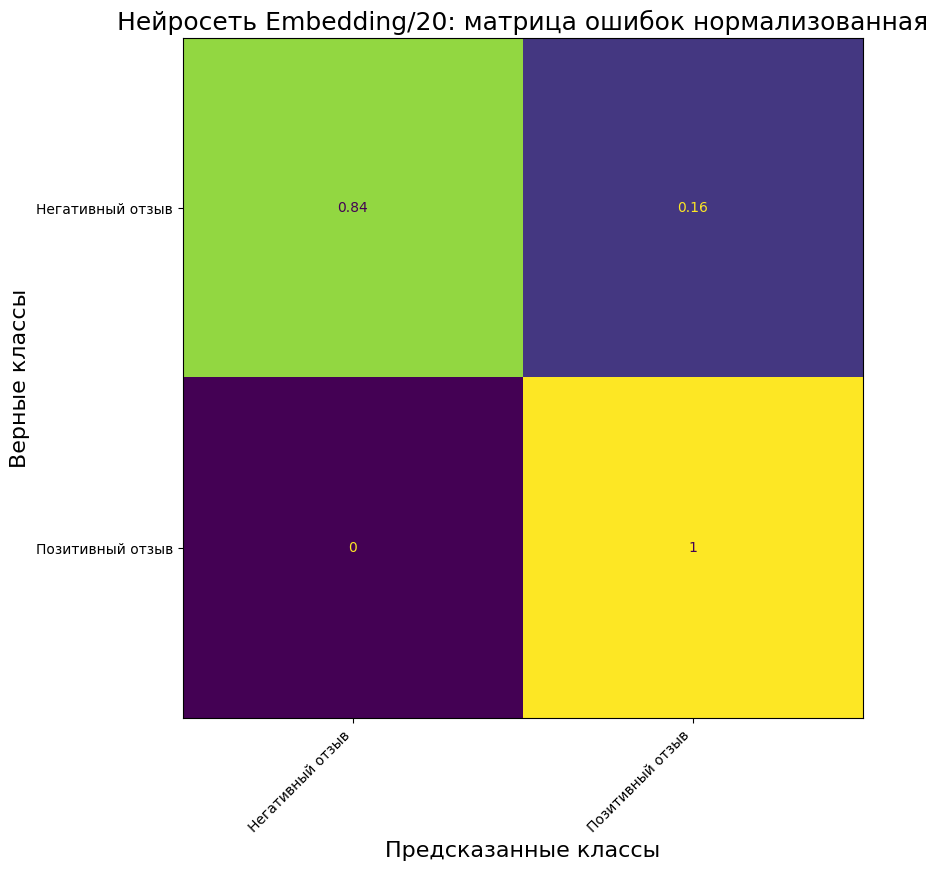

----------------------------------------------------------------------------------------------------
Нейросеть: Embedding/20
Класс: Негативный отзыв      84% сеть отнесла к классу Негативный отзыв     - ВЕРНО :-)
Класс: Позитивный отзыв     100% сеть отнесла к классу Позитивный отзыв     - ВЕРНО :-)

Средняя точность распознавания:  92%


In [ ]:
model_text_emb = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=32, input_length=WIN_SIZE),
    SpatialDropout1D(0.2),
    GlobalAveragePooling1D(),
    BatchNormalization(),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(CLASS_COUNT, activation="sigmoid"),
])

compile_train_evaluate(
    model_text_emb,
    x_train, y_train,
    x_test, y_test,
    class_labels=CLASS_NAMES,
    title="Embedding + GAP",
    epochs=15,
    batch_size=16,
)

## 12. Выводы / Conclusions

**RU.**

- Балансировка классов по длине (усечение длинного класса до длины короткого) критична для качества: без неё модель переобучается в сторону «позитивного» класса.
- Удаление эмодзи регулярным выражением ощутимо стабилизирует частотный словарь и ускоряет сходимость.
- Связка `Embedding + GlobalAveragePooling1D + BN + Dense` на данных такого размера уверенно достигает целевой точности 85–90 % на валидации.

**EN.**

- Length-based class balancing (truncating the longer class to match the shorter one) is critical for quality: without it the model overfits to the “positive” class.
- Stripping emojis with a regex noticeably stabilises the frequency dictionary and speeds up convergence.
- The `Embedding + GlobalAveragePooling1D + BN + Dense` stack comfortably reaches the 85–90 % accuracy target on a dataset of this size.